# Ames Housing — Machine Learning Models

## Load Packages

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import sklearn.metrics as metrics

from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import tensorflow as tf

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid')

TARGET = 'logSalePrice'
SKIP   = ['SalePrice', 'logSalePrice', 'Id', 'is_train']

## Load Data

In [3]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')
df_train.head()

Train: (1460, 81)  |  Test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Feature Engineering

In [4]:
# Tag origin, combine so encoding is consistent across train and test
df_train['is_train'] = 1
df_test['is_train']  = 0
df_test['SalePrice'] = np.nan

df_all = pd.concat([df_train, df_test], ignore_index=True)

# Structural missings: NaN means the feature is absent, not unknown
fill_zero = ['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath','BsmtHalfBath','GarageArea','GarageCars','MasVnrArea']
df_all[fill_zero] = df_all[fill_zero].fillna(0)
df_all['GarageYrBlt'] = df_all['GarageYrBlt'].fillna(df_all['YearBuilt'])

# Derived features
df_all['TotalSqftCalc']    = df_all['BsmtFinSF1'] + df_all['BsmtFinSF2'] + df_all['GrLivArea']
df_all['TotalFloorSF']     = df_all['1stFlrSF']   + df_all['2ndFlrSF']
df_all['HouseAge']         = df_all['YrSold']      - df_all['YearBuilt']
df_all['RemodAge']         = df_all['YrSold']      - df_all['YearRemodAdd']
df_all['GarageAge']        = df_all['YrSold']      - df_all['GarageYrBlt']
df_all['TotalBath']        = (df_all['FullBath'] + df_all['HalfBath'] * 0.5
                              + df_all['BsmtFullBath'] + df_all['BsmtHalfBath'] * 0.5)
df_all['QualityIndex']     = df_all['OverallQual'] * df_all['OverallCond']
df_all['TotalOutdoorSF']   = (df_all['WoodDeckSF']  + df_all['OpenPorchSF']
                              + df_all['EnclosedPorch'] + df_all['ScreenPorch'])
df_all['logTotalSqftCalc'] = np.log(df_all['TotalSqftCalc'])
df_all['logSalePrice']     = np.log(df_all['SalePrice'])   # NaN for test rows — never used as a feature

df_all[['TotalSqftCalc','HouseAge','TotalBath','QualityIndex','logTotalSqftCalc']].describe()

,TotalSqftCalc,HouseAge,TotalBath,QualityIndex,logTotalSqftCalc
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,1991.597122,36.479959,2.218397,33.735868,7.530627
std,760.609067,30.336182,0.808840,9.186204,0.363966
min,334.000000,-1.000000,1.000000,1.000000,5.811141
25%,1490.500000,7.000000,1.500000,30.000000,7.306867
50%,1850.000000,35.000000,2.000000,35.000000,7.522941
75%,2378.500000,54.500000,2.500000,40.000000,7.774225
max,11286.000000,136.000000,7.000000,90.000000,9.331318


In [5]:
# Fill remaining numeric NaN with median; categorical NaN with 'None'
# ('None' is meaningful here — most missing categoricals mean "no such feature")
num_cols = [c for c in df_all.select_dtypes(include=[np.number]).columns if c not in SKIP]
cat_cols =  df_all.select_dtypes(include='object').columns.tolist()

df_all[num_cols] = df_all[num_cols].fillna(df_all[num_cols].median())
df_all[cat_cols] = df_all[cat_cols].fillna('None')

print(f'Remaining numeric NaN:      {df_all[num_cols].isnull().sum().sum()}')
print(f'Remaining categorical NaN:  {df_all[cat_cols].isnull().sum().sum()}')

Remaining numeric NaN:      0
Remaining categorical NaN:  0


In [6]:
# One-hot encode all categorical columns, then split back
df_all = pd.get_dummies(df_all, columns=cat_cols, dtype=int)

train_processed = df_all[df_all['is_train'] == 1].drop('is_train', axis=1).copy()
test_processed  = df_all[df_all['is_train'] == 0].drop('is_train', axis=1).copy()

feature_cols = [c for c in train_processed.columns if c not in SKIP]

# Hard stop if any feature NaN slipped through
n_missing = train_processed[feature_cols].isnull().sum().sum()
assert n_missing == 0, f"{n_missing} missing values remain — check preprocessing"

print(f'Train: {train_processed.shape}  |  Test: {test_processed.shape}')
print(f'Feature columns: {len(feature_cols)}  |  Missing in train features: {n_missing}')

Train: (1460, 322)  |  Test: (1459, 322)
Feature columns: 319  |  Missing in train features: 0


## EDA

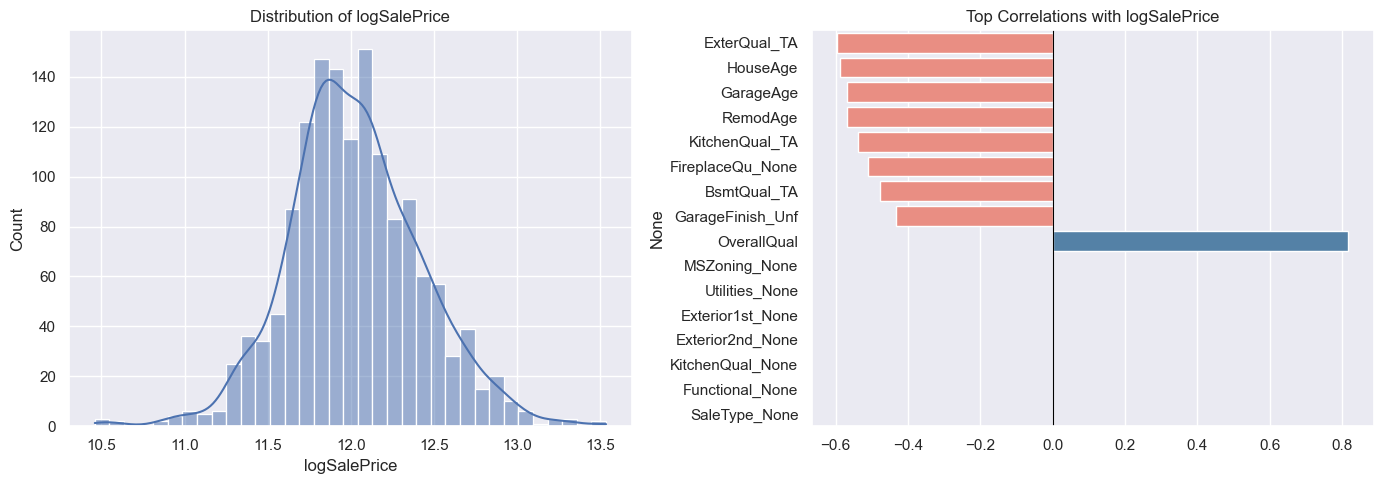

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of log-transformed target
sns.histplot(data=train_processed, x='logSalePrice', kde=True, ax=axs[0])
axs[0].set_title('Distribution of logSalePrice')

# Top correlations with logSalePrice — numeric feature columns only
num_feat_cols = train_processed[feature_cols].select_dtypes(include=[np.number]).columns
corr = (train_processed[num_feat_cols]
        .corrwith(train_processed['logSalePrice'])
        .sort_values())
top_corr = pd.concat([corr.head(8), corr.tail(8)])

colors = ['salmon' if v < 0 else 'steelblue' for v in top_corr.values]
sns.barplot(x=top_corr.values, y=top_corr.index, palette=colors, ax=axs[1])
axs[1].axvline(0, color='black', linewidth=0.8)
axs[1].set_title('Top Correlations with logSalePrice')

plt.tight_layout()
plt.show()

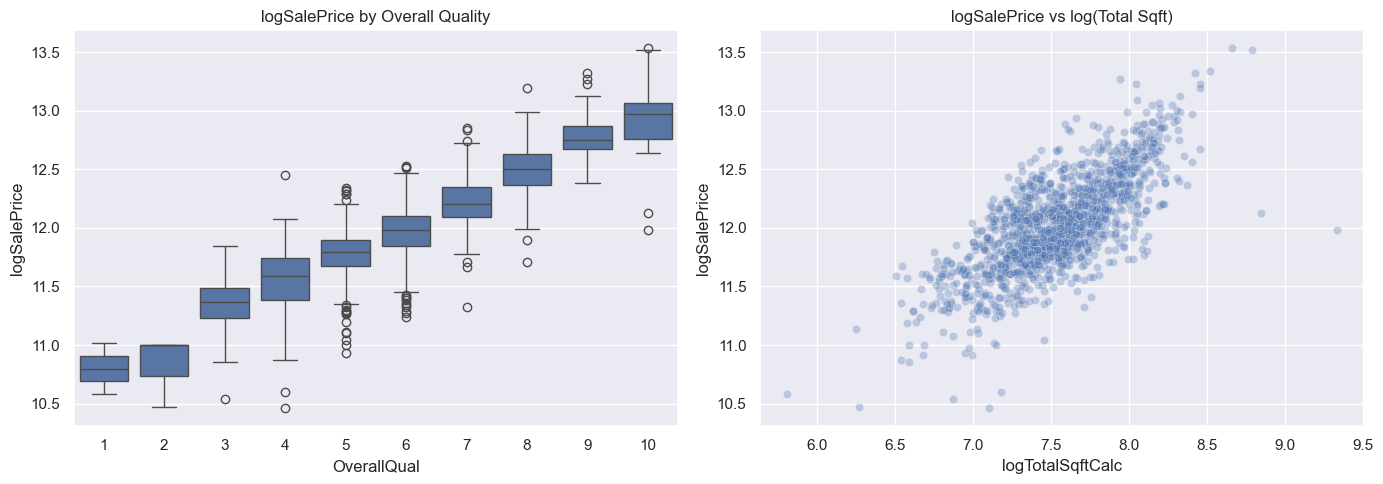

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='OverallQual', y='logSalePrice', data=train_processed, ax=axs[0])
axs[0].set_title('logSalePrice by Overall Quality')

sns.scatterplot(x='logTotalSqftCalc', y='logSalePrice',
                data=train_processed, alpha=0.3, ax=axs[1])
axs[1].set_title('logSalePrice vs log(Total Sqft)')

plt.tight_layout()
plt.show()

## Models

In [9]:
def getRMSE(name, model, X, Y):
    pred = model.predict(X)
    if hasattr(pred, 'flatten'):
        pred = pred.flatten()
    return [name, np.sqrt(metrics.mean_squared_error(Y, pred))]

def getTopFeatures(model, varNames):
    """Return feature names with above-average importance, sorted descending."""
    imp = model.feature_importances_
    avg = imp.mean()
    ranked = sorted(zip(varNames, imp), key=lambda x: -x[1])
    return [name for name, val in ranked if val > avg]

In [10]:
X = train_processed[feature_cols]
Y = train_processed[TARGET]

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=5)
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}')

X_train: (1168, 319)  |  X_val: (292, 319)


### Decision Tree

In [11]:
WHO = 'TREE'

TREE_MODEL = tree.DecisionTreeRegressor(max_depth=6, random_state=5)
TREE_MODEL.fit(X_train, Y_train)

TRAIN_TREE = getRMSE(WHO + '_Train', TREE_MODEL, X_train, Y_train)
VAL_TREE   = getRMSE(WHO,            TREE_MODEL, X_val,   Y_val)

print(f'{WHO}  —  Train RMSE: {TRAIN_TREE[1]:.4f}  |  Val RMSE: {VAL_TREE[1]:.4f}')

TREE  —  Train RMSE: 0.1235  |  Val RMSE: 0.2156


### Random Forest

In [12]:
WHO = 'RF'

RF_MODEL = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=5)
RF_MODEL.fit(X_train, Y_train)

TRAIN_RF = getRMSE(WHO + '_Train', RF_MODEL, X_train, Y_train)
VAL_RF   = getRMSE(WHO,            RF_MODEL, X_val,   Y_val)

print(f'{WHO}  —  Train RMSE: {TRAIN_RF[1]:.4f}  |  Val RMSE: {VAL_RF[1]:.4f}')

RF_features = getTopFeatures(RF_MODEL, feature_cols)
print(f'{len(RF_features)} features above average importance')

RF  —  Train RMSE: 0.0542  |  Val RMSE: 0.1355
23 features above average importance


### Gradient Boosting

In [13]:
WHO = 'GB'

GB_MODEL = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                     max_depth=4, random_state=5)
GB_MODEL.fit(X_train, Y_train)

TRAIN_GB = getRMSE(WHO + '_Train', GB_MODEL, X_train, Y_train)
VAL_GB   = getRMSE(WHO,            GB_MODEL, X_val,   Y_val)

print(f'{WHO}  —  Train RMSE: {TRAIN_GB[1]:.4f}  |  Val RMSE: {VAL_GB[1]:.4f}')

GB_features = getTopFeatures(GB_MODEL, feature_cols)
print(f'\n{len(GB_features)} features above average importance (top 10):')
for name, val in sorted(zip(feature_cols, GB_MODEL.feature_importances_),
                         key=lambda x: -x[1])[:10]:
    print(f'  {name}: {val:.4f}')

GB  —  Train RMSE: 0.0561  |  Val RMSE: 0.1194

22 features above average importance (top 10):
  OverallQual: 0.4589
  TotalSqftCalc: 0.0941
  logTotalSqftCalc: 0.0872
  TotalFloorSF: 0.0624
  QualityIndex: 0.0381
  HouseAge: 0.0294
  TotalBsmtSF: 0.0222
  GarageCars: 0.0196
  LotArea: 0.0194
  TotalBath: 0.0192


### Stepwise Regression

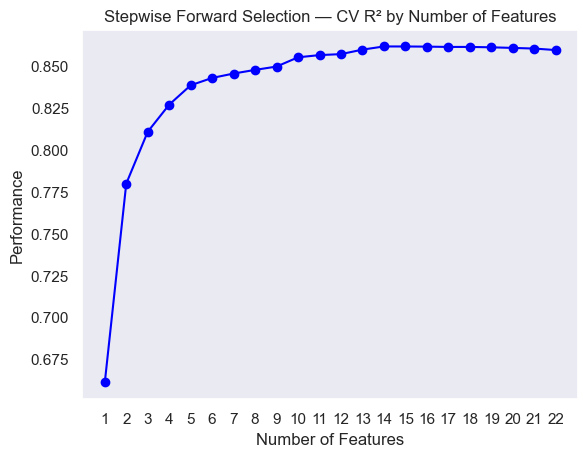

Selected 14 features:
  OverallQual
  TotalSqftCalc
  logTotalSqftCalc
  QualityIndex
  HouseAge
  TotalBsmtSF
  GarageCars
  LotArea
  RemodAge
  GrLivArea
  KitchenQual_TA
  Fireplaces
  MSZoning_RL
  TotalOutdoorSF


In [14]:
WHO = 'STEP'

# Use GB-selected features as the candidate pool for forward selection
V_train   = X_train[GB_features]
V_val     = X_val[GB_features]
stepNames = list(V_train.columns)

sfs = SFS(LinearRegression(),
          k_features=(1, len(GB_features)),
          forward=True,
          floating=False,
          scoring='r2',
          cv=5)
sfs.fit(V_train, Y_train)

fig = plot_sfs(sfs.get_metric_dict(), kind=None)
plt.title('Stepwise Forward Selection — CV R² by Number of Features')
plt.grid()
plt.show()

# Best feature subset: highest mean CV R²
dfm = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
dfm['avg_score'] = dfm['avg_score'].astype(float)
best_k = int(dfm['avg_score'].idxmax())

# Compatible with both old mlxtend (returns index strings) and new (returns column names)
raw_names     = sfs.get_metric_dict()[best_k]['feature_names']
finalStepVars = [stepNames[int(n)] if str(n).isdigit() else str(n) for n in raw_names]

print(f'Selected {len(finalStepVars)} features:')
for v in finalStepVars:
    print(f'  {v}')

In [15]:
STEP_MODEL = LinearRegression()
STEP_MODEL.fit(X_train[finalStepVars], Y_train)

TRAIN_STEP = getRMSE(WHO + '_Train', STEP_MODEL, X_train[finalStepVars], Y_train)
VAL_STEP   = getRMSE(WHO,            STEP_MODEL, X_val[finalStepVars],   Y_val)

print(f'{WHO}  —  Train RMSE: {TRAIN_STEP[1]:.4f}  |  Val RMSE: {VAL_STEP[1]:.4f}')

STEP  —  Train RMSE: 0.1388  |  Val RMSE: 0.1326


### TensorFlow

In [16]:
WHO = 'TF'

# Scale to [0,1] using only training data — same scaler applied to val and test
theScaler = MinMaxScaler()
theScaler.fit(X_train[GB_features])

TF_Xtrain = theScaler.transform(X_train[GB_features])
TF_Xval   = theScaler.transform(X_val[GB_features])

nFeatures = TF_Xtrain.shape[1]
nUnits    = max(int(nFeatures * 2 / 3), 32)

TF_MODEL = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(nFeatures,)),
    tf.keras.layers.Dense(nUnits, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(nUnits, activation='relu'),
    tf.keras.layers.Dense(1,      activation='linear')
])
TF_MODEL.compile(loss='mse', optimizer='adam')
TF_MODEL.fit(TF_Xtrain, Y_train, epochs=100, verbose=False)

train_preds_tf = TF_MODEL.predict(TF_Xtrain, verbose=0).flatten()
val_preds_tf   = TF_MODEL.predict(TF_Xval,   verbose=0).flatten()

TRAIN_TF = [WHO + '_Train', np.sqrt(metrics.mean_squared_error(Y_train, train_preds_tf))]
VAL_TF   = [WHO,            np.sqrt(metrics.mean_squared_error(Y_val,   val_preds_tf))]

print(f'{WHO}  —  Train RMSE: {TRAIN_TF[1]:.4f}  |  Val RMSE: {VAL_TF[1]:.4f}')

E0000 00:00:1780965001.574382   30723 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780965001.574798   30978 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780965001.593506   30723 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


TF  —  Train RMSE: 0.3193  |  Val RMSE: 0.3293


### Model Comparison

In [17]:
ALL_RESULTS = sorted([VAL_TREE, VAL_RF, VAL_GB, VAL_STEP, VAL_TF], key=lambda x: x[1])

print('Model Comparison — Validation RMSE (log scale, lower is better)')
print('=' * 52)
for name, rmse in ALL_RESULTS:
    tag = '  ← best' if name == ALL_RESULTS[0][0] else ''
    print(f'{name:<12}  RMSE: {rmse:.4f}{tag}')

BEST_NAME = ALL_RESULTS[0][0]

Model Comparison — Validation RMSE (log scale, lower is better)
GB            RMSE: 0.1194  ← best
STEP          RMSE: 0.1326
RF            RMSE: 0.1355
TREE          RMSE: 0.2156
TF            RMSE: 0.3293


## Test Prediction

In [18]:
# Align test columns to training feature set (same order, same columns)
X_test_kaggle = test_processed[feature_cols]

# Predict with all models and back-transform from log scale
preds = {
    'TREE': np.exp(TREE_MODEL.predict(X_test_kaggle)),
    'RF':   np.exp(RF_MODEL.predict(X_test_kaggle)),
    'GB':   np.exp(GB_MODEL.predict(X_test_kaggle)),
    'STEP': np.exp(STEP_MODEL.predict(X_test_kaggle[finalStepVars])),
    'TF':   np.exp(TF_MODEL.predict(
                theScaler.transform(X_test_kaggle[GB_features]), verbose=0
            ).flatten())
}

submission = pd.DataFrame({
    'Id':        test_processed['Id'].astype(int).values,
    'SalePrice': preds[BEST_NAME]
})

submission.to_csv('submission.csv', index=False)
print(f'Submission saved — predictions from: {BEST_NAME}')
print(submission['SalePrice'].describe())
submission.head()

Submission saved — predictions from: GB
count      1459.000000
mean     177610.469549
std       76025.055933
min       49197.601836
25%      127611.877803
50%      156537.156376
75%      206092.696831
max      562399.584742
Name: SalePrice, dtype: float64


,Id,SalePrice
0,1461,129236.179982
1,1462,158028.982348
2,1463,182595.165611
3,1464,189718.947434
4,1465,185252.970585
